In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.datasets import make_regression, make_classification



In [3]:
x, y = make_regression(n_samples=10, n_features=1)
x, y

(array([[-0.42131006],
        [-0.25124668],
        [ 0.37034451],
        [-0.24473266],
        [-1.99466439],
        [-2.04917353],
        [ 0.34609409],
        [ 1.3099041 ],
        [-2.01330753],
        [ 0.96361796]]),
 array([-0.37092179, -0.22119782,  0.32605167, -0.21546288, -1.75610448,
        -1.80409438,  0.30470158,  1.15324085, -1.77251792,  0.8483702 ]))

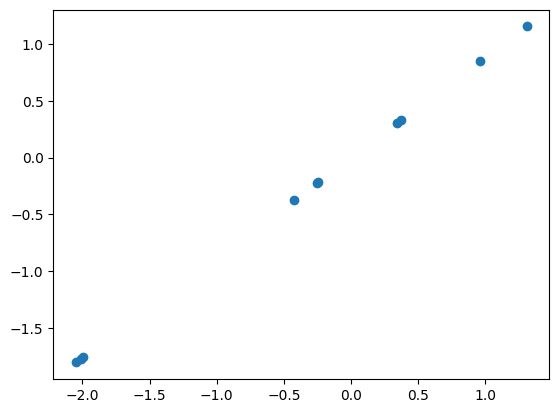

In [5]:
plt.scatter(x, y);

In [7]:
x, y = make_regression(n_samples=200, n_features=1, noise=15, random_state=42)
x.shape, y.shape

((200, 1), (200,))

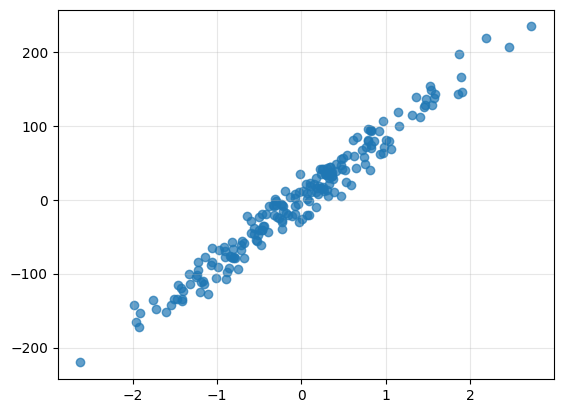

In [10]:
plt.scatter(x, y, alpha=0.7);
plt.grid(True, alpha=0.3);

In [12]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((160, 1), (40, 1), (160,), (40,))

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()


In [15]:
x_train_scaled = x_scaler.fit_transform(x_train)
x_test_scaled = x_scaler.transform(x_test)

In [16]:
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1))

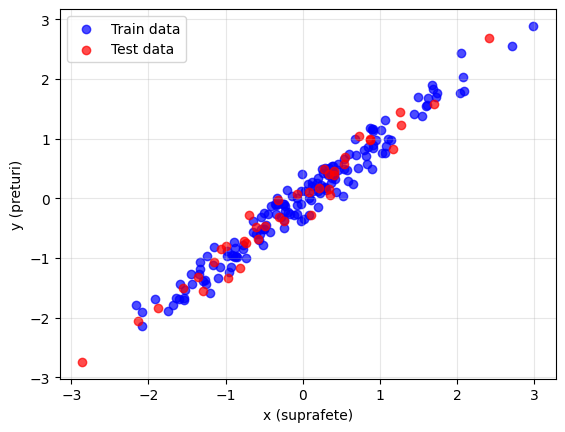

In [27]:
plt.scatter(x_train_scaled, y_train_scaled, alpha=0.7, c="blue", label="Train data");
plt.scatter(x_test_scaled, y_test_scaled,  alpha=0.7, c="red", label="Test data");
plt.grid(True, alpha=0.3);
plt.xlabel("x (suprafete)");
plt.ylabel("y (preturi)");
plt.legend();

In [45]:
model_lin = tf.keras.Sequential([
    ## INPUT
    tf.keras.layers.Input(shape=(1,)),

    ## OUTPUT
    tf.keras.layers.Dense(1),
])

model_lin.compile(optimizer="adam", loss="mse", metrics=["mae"])

model_lin.summary()




Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [46]:
model_history = model_lin.fit(x_train, y_train, epochs=250, verbose=0)


In [35]:
type(model_history)

keras.src.callbacks.history.History

In [51]:
# model_history.history

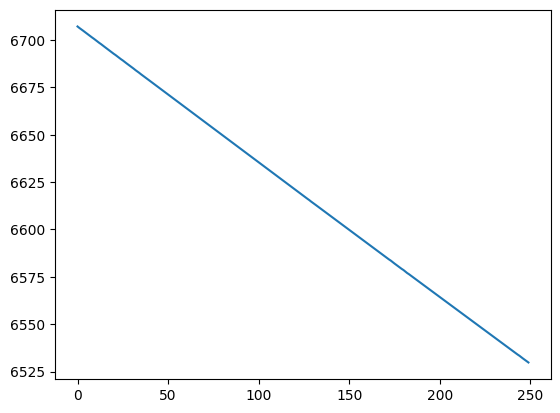

In [49]:
plt.plot(model_history.history["loss"], label="loss")


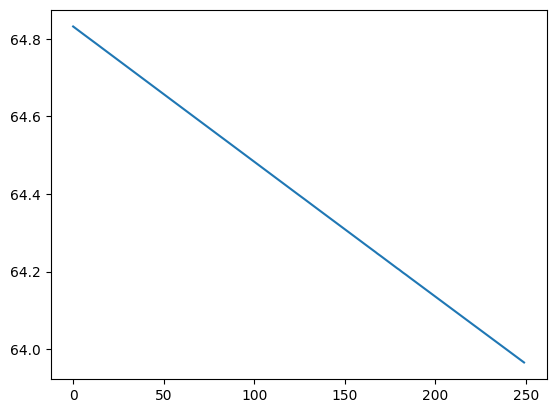

In [50]:
plt.plot(model_history.history["mae"], label="mae")

# Imbunatatirea modelului

In [52]:
model_improv = tf.keras.Sequential([
    ## INPUT
    tf.keras.layers.Input(shape=(1,)),

    tf.keras.layers.Dense(16, activation="relu"),

    ## OUTPUT
    tf.keras.layers.Dense(1),
])

model_improv.compile(optimizer="adam", loss="mse", metrics=["mae"])

model_improv.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49 (196.00 B)

 Trainable params: 49 (196.00 B)

 Non-trainable params: 0 (0.00 B)

In [54]:
model_history = model_improv.fit(x_train, y_train, epochs=10, validation_split=0.2 )

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 434ms/step - loss: 6759.6206 - mae: 65.5161 - val_loss: 5588.4580 - val_mae: 57.6504
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 6756.1016 - mae: 65.4965 - val_loss: 5585.9053 - val_mae: 57.6345
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 6752.5503 - mae: 65.4773 - val_loss: 5583.2705 - val_mae: 57.6180
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 6748.9492 - mae: 65.4579 - val_loss: 5580.5640 - val_mae: 57.6012
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 6745.2007 - mae: 65.4378 - val_loss: 5577.8320 - val_mae: 57.5843
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 6741.7158 - mae: 65.4191 - val_loss: 5575.1401 - val_mae: 57.5676
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 6738.1709 - mae: 65.3998 - val_loss: 5572.4136 - val_mae: 57.5508
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 6734.4492 - mae: 65.3807 - val_loss: 5569.7026 - val_mae: 57.5340
Epoch 9/10
4/4

In [55]:
model_history.history

{'loss': [6759.62060546875,
  6756.1015625,
  6752.55029296875,
  6748.94921875,
  6745.20068359375,
  6741.7158203125,
  6738.1708984375,
  6734.44921875,
  6730.9384765625,
  6727.2822265625],
 'mae': [65.51608276367188,
  65.49647521972656,
  65.47727966308594,
  65.45790100097656,
  65.4377670288086,
  65.41909790039062,
  65.3997802734375,
  65.38068389892578,
  65.36167907714844,
  65.34262084960938],
 'val_loss': [5588.4580078125,
  5585.9052734375,
  5583.2705078125,
  5580.56396484375,
  5577.83203125,
  5575.14013671875,
  5572.41357421875,
  5569.70263671875,
  5566.9384765625,
  5564.1611328125],
 'val_mae': [57.65036392211914,
  57.63451385498047,
  57.61804962158203,
  57.60120391845703,
  57.58431625366211,
  57.567626953125,
  57.550750732421875,
  57.5340461730957,
  57.51716995239258,
  57.50029754638672]}

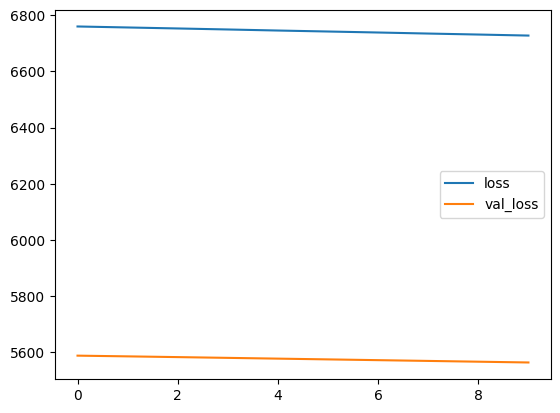

In [56]:
plt.plot(model_history.history["loss"], label="loss")
plt.plot(model_history.history["val_loss"], label="val_loss")
plt.legend()

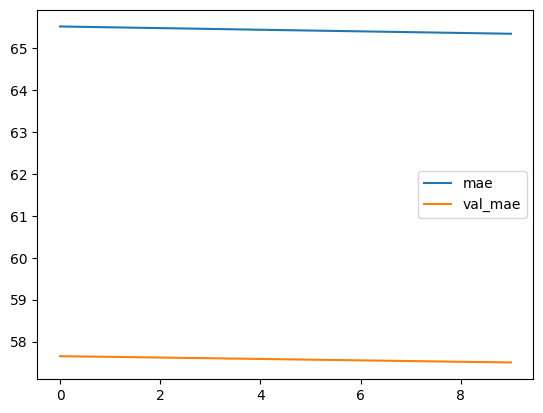

In [57]:
plt.plot(model_history.history["mae"], label="mae")
plt.plot(model_history.history["val_mae"], label="val_mae")
plt.legend()

# Ridicare numarului de epoci

In [58]:
model_improv_epoci = tf.keras.Sequential([
    ## INPUT
    tf.keras.layers.Input(shape=(1,)),

    tf.keras.layers.Dense(16, activation="relu"),

    ## OUTPUT
    tf.keras.layers.Dense(1),
])

model_improv_epoci.compile(optimizer="adam", loss="mse", metrics=["mae"])

model_improv_epoci.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49 (196.00 B)

 Trainable params: 49 (196.00 B)

 Non-trainable params: 0 (0.00 B)

In [59]:
model_history = model_improv_epoci.fit(x_train, y_train, epochs=500, validation_split=0.2, verbose=0)

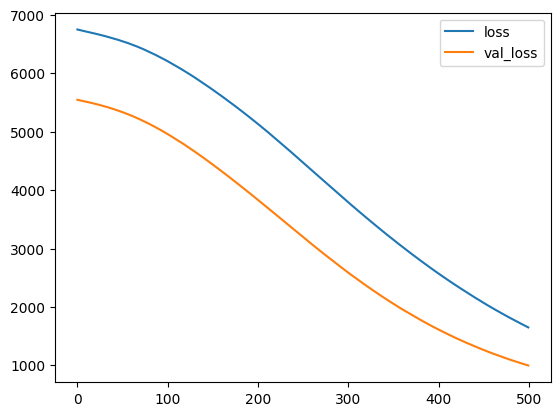

In [60]:
plt.plot(model_history.history["loss"], label="loss")
plt.plot(model_history.history["val_loss"], label="val_loss")
plt.legend()